In [1]:
import sys
print(sys.executable)


c:\Users\aravi\OneDrive\Desktop\ai-energy-trading-platform\.venv\Scripts\python.exe


In [2]:
import pandas as pd

DATA_PATH = "../data/processed/clean_energy_weather.csv"

print("Loading processed dataset...")

df = pd.read_csv(DATA_PATH)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Loading processed dataset...

Dataset Shape:
(78888, 9)

Columns:
Index(['YEAR', 'MO', 'DY', 'HR', 'T2M', 'WS10M', 'ALLSKY_SFC_SW_DWN', 'RH2M',
       'timestamp'],
      dtype='str')

First 5 Rows:
   YEAR  MO  DY  HR    T2M  WS10M  ALLSKY_SFC_SW_DWN   RH2M  \
0  2015   1   1   0  20.57   1.78                0.0  74.05   
1  2015   1   1   1  20.55   1.70                0.0  74.20   
2  2015   1   1   2  20.37   1.92                0.0  75.50   
3  2015   1   1   3  20.05   2.20                0.0  77.70   
4  2015   1   1   4  19.62   2.51                0.0  80.61   

             timestamp  
0  2015-01-01 00:00:00  
1  2015-01-01 01:00:00  
2  2015-01-01 02:00:00  
3  2015-01-01 03:00:00  
4  2015-01-01 04:00:00  


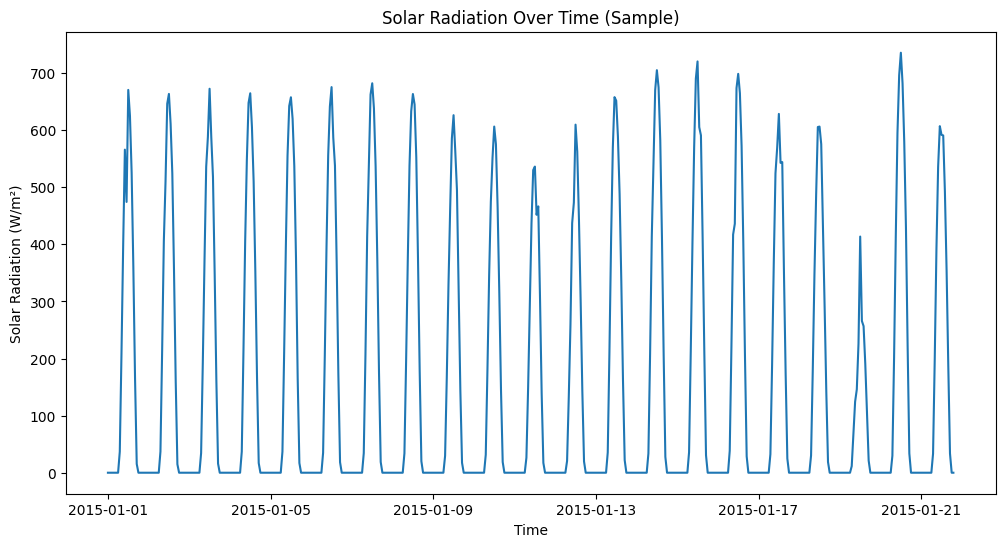

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../data/processed/clean_energy_weather.csv"

df = pd.read_csv(DATA_PATH)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

plt.figure(figsize=(12,6))

plt.plot(df["timestamp"][:500], df["ALLSKY_SFC_SW_DWN"][:500])

plt.title("Solar Radiation Over Time (Sample)")
plt.xlabel("Time")
plt.ylabel("Solar Radiation (W/m²)")

plt.show()

HR
0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
5       1.149531
6      37.087968
7     160.353127
8     347.388235
9     532.688010
10    682.800824
11    766.902978
12    788.765497
13    741.714944
14    640.113237
15    471.365211
16    279.347368
17    105.612464
18     15.784134
19      0.000000
20      0.000000
21      0.000000
22      0.000000
23      0.000000
Name: ALLSKY_SFC_SW_DWN, dtype: float64


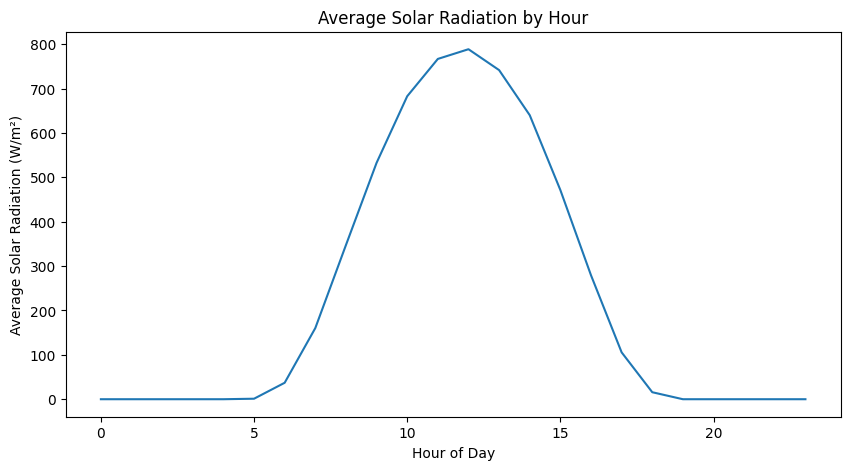

In [5]:
# Average solar radiation by hour

hourly_solar = df.groupby("HR")["ALLSKY_SFC_SW_DWN"].mean()

print(hourly_solar)

plt.figure(figsize=(10,5))

plt.plot(hourly_solar.index, hourly_solar.values)

plt.title("Average Solar Radiation by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Solar Radiation (W/m²)")

plt.show()

HR
0     3.138917
1     3.115470
2     3.108403
3     3.124974
4     3.170012
5     3.250876
6     3.427910
7     3.713277
8     3.826152
9     3.699151
10    3.554490
11    3.535449
12    3.745044
13    4.106933
14    4.470605
15    4.729258
16    4.814028
17    4.650876
18    4.371652
19    4.052349
20    3.732452
21    3.473274
22    3.293441
23    3.187362
Name: WS10M, dtype: float64


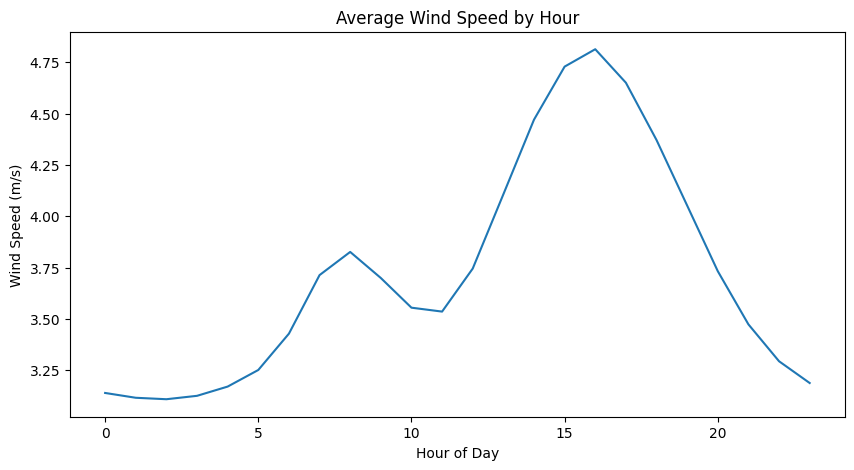

In [6]:
# Average wind speed by hour

hourly_wind = df.groupby("HR")["WS10M"].mean()

print(hourly_wind)

plt.figure(figsize=(10,5))

plt.plot(hourly_wind.index, hourly_wind.values)

plt.title("Average Wind Speed by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Wind Speed (m/s)")

plt.show()

                        T2M     WS10M  ALLSKY_SFC_SW_DWN      RH2M
T2M                1.000000 -0.044829           0.439334 -0.504062
WS10M             -0.044829  1.000000           0.104132 -0.094368
ALLSKY_SFC_SW_DWN  0.439334  0.104132           1.000000 -0.656414
RH2M              -0.504062 -0.094368          -0.656414  1.000000


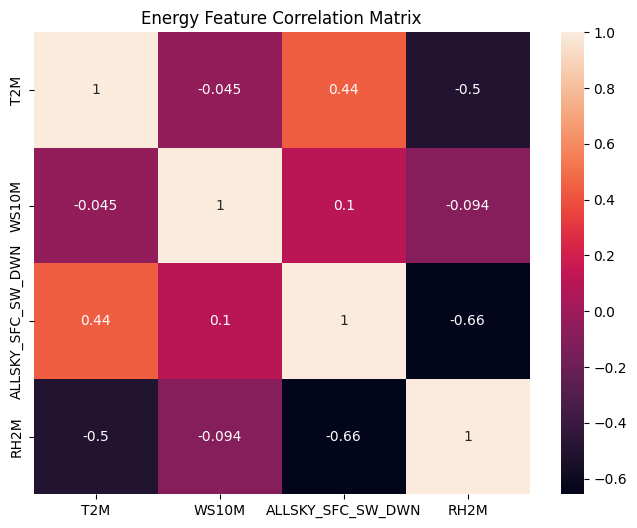

In [7]:
import seaborn as sns

# Select only numeric columns
energy_features = ["T2M", "WS10M", "ALLSKY_SFC_SW_DWN", "RH2M"]

correlation_matrix = df[energy_features].corr()

print(correlation_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True)

plt.title("Energy Feature Correlation Matrix")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Features
X = df[["T2M", "WS10M", "RH2M", "HR"]]

# Target
y = df["ALLSKY_SFC_SW_DWN"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 182.07961919506005


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 33.618559513246296


In [10]:
import pandas as pd

# Get feature importance
importance = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

# Sort
importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

  Feature  Importance
3      HR    0.504613
2    RH2M    0.445664
0     T2M    0.033540
1   WS10M    0.016182


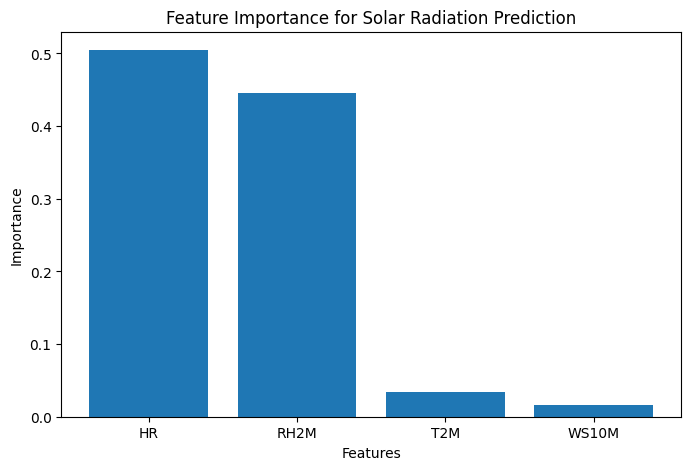

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(importance_df["Feature"], importance_df["Importance"])

plt.title("Feature Importance for Solar Radiation Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()